In [1]:
import pennylane as qml
import itertools 
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np # 用于数据加载
import matplotlib.pyplot as plt
from itertools import combinations
from math import log2
import random



In [2]:
import os
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop","QPR","数据")

os.chdir(desktop_path)

In [3]:
num_qubits=9
# layers= 3
NUM_QUBITS = 9
# MODEL_LAYERS = 3


In [4]:
# 电路14 U
dev = qml.device('default.qubit', wires=num_qubits)
@qml.qnode(dev,interface='torch',diff_method='backprop')
def circ_14(input,n_wires,x,layers):
    counter = itertools.count(0)
    qml.QubitStateVector(input, wires = range(n_wires),normalize=True)
    for _ in range(layers):
            for i in range(n_wires):
                qml.RY(x[next(counter)],wires = i)
            for i in range(n_wires):
                qml.CRX(x[next(counter)],wires = [i,(i+1)%n_wires])
            for i in range(n_wires):
                qml.RY(x[next(counter)],wires = i)  
            for i in range(1,n_wires):
                qml.CRX(x[next(counter)],wires = [i,(i-1)%n_wires])
            qml.CRX(x[next(counter)],wires = [0,n_wires-1])
    return qml.state()


In [5]:
def pairwise_inner_products(psi):
    """
    计算量子态在所有比特对上的内积矩阵（保持可微分）
    参数:
        psi: torch 张量，长度必须是 2^n
    返回:
        inner_matrix: torch.Tensor, [n, n]
    """
    n_qubits = int(log2(len(psi)))
    dev = qml.device("default.qubit", wires=1 + n_qubits, shots=None)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(q1, q2):
        ancilla = 0
        # 加载态
        qml.QubitStateVector(psi, wires=range(1, 1 + n_qubits), normalize=True)
        # 交换测试
        qml.Hadamard(wires=ancilla)
        qml.CSWAP(wires=[ancilla, q1, q2])
        qml.Hadamard(wires=ancilla)
        return qml.probs(wires=ancilla)
        
    inner_matrix = torch.zeros((n_qubits, n_qubits), dtype=torch.float64)

    # 所有比特对
    wires = list(range(1, 1 + n_qubits))
    for i, j in combinations(wires, 2):
        probs = circuit(i, j)
        p0 = probs[0]
        # 计算内积幅值 |<ψ_i|ψ_j>|
        inner = torch.sqrt(torch.clamp(2 * p0 - 1, min=0.0))
        # 写入对称矩阵
        inner_matrix[i-1, j-1] = inner
        inner_matrix[j-1, i-1] = inner

    # 自身内积设为 1
    idx = torch.arange(n_qubits)
    inner_matrix[idx, idx] = 1.0
    # inner_matrix_softmax = torch.softmax(inner_matrix, dim=-1)

    return inner_matrix

In [6]:
dev = qml.device("default.qubit", wires=num_qubits, shots=None)
@qml.qnode(dev,interface='torch',diff_method="backprop")

def measure_z(psi,num_qubits):
    qml.QubitStateVector(psi, wires=range(num_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

In [7]:
class Quixer(nn.Module):
    def __init__(self, num_qubits, layers,dropout_rate=0.1):
        super().__init__()
        # random.seed(42)

        # torch.manual_seed(42)
        # 统一使用 float64 精度
        DTYPE = torch.float64
        
        self.qubits = num_qubits
        self.layers = layers
        self.dropout_rate = dropout_rate
        
        # 1. 量子参数 gate_p_q 统一为 float64 (默认 torch.rand 返回 float32，需显式转换)
        self.gate_p_q = torch.nn.Parameter(
            torch.rand(4 * layers * num_qubits, requires_grad=True, dtype=DTYPE)
        )
        # 2. 经典输出层 output_feedforward 统一为 float64
        self.output_feedforward = torch.nn.Sequential(
            # 输入维度是 num_qubits (N), 输出维度是 3
            # torch.nn.Linear(int(self.qubits), 3, dtype=DTYPE)
            torch.nn.Linear(int(self.qubits * (self.qubits - 1) // 2), 3, dtype=DTYPE)
        )

    def forward(self, x):
        # x.shape[0] 是 batch size
        out_sum = torch.empty(x.shape[0], 3, dtype=self.output_feedforward[0].weight.dtype)
        
        # 循环遍历 batch 中的每个样本
        for i in range(x.shape[0]):
            # state_q 是 complex128 (来自 circ_14)
            state_q = circ_14(x[i], self.qubits, self.gate_p_q, self.layers)
            # quantum_out: [N, N] float64 (来自 pairwise_inner_products)
            matrix = pairwise_inner_products(state_q)
            mask = torch.triu(torch.ones_like(matrix), diagonal=1).bool()
            upper_tri_vector = matrix[mask]

            # 3. 输入到经典层时不需要 .float()，因为 output_feedforward 期望 float64
            out = self.output_feedforward(upper_tri_vector)
            out_sum[i] = out
            
        return out_sum,matrix

In [8]:
def accuracy_fn(y_true, y_pred):
    # 1.torch.eq() 用于逐元素地比较两个张量的相等性。它返回一个新的布尔张量，其中每个元素都表示对应位置上的元素是否相等。
    # 2.使用 .sum() 方法对布尔张量进行求和操作，将所有为 True 的元素加起来。
    # 3.使用 .item() 方法将结果转换为 Python 的标量值。
    correct = torch.eq(y_true, y_pred).sum().item() 
    acc = (correct / len(y_pred)) * 100 
    return acc

In [9]:
# 1. 加载复数数据
inputs1 = np.loadtxt('9input.txt', dtype=complex)
outputs = np.loadtxt('9output.txt')

In [10]:
# 2. 转换为 PyTorch float 张量
inputs_all = torch.from_numpy(inputs1)
outputs_all = torch.from_numpy(outputs).long()

# 3. 【新要求实现】
# 训练集池和测试集都使用整个数据集 (0-2499)
x_train_full = inputs_all
y_train_full = outputs_all
x_test = inputs_all
y_test = outputs_all

print(f"数据加载完成。x_train 形状：{x_train_full.shape}，y_train 形状：{y_train_full.shape}")

数据加载完成。x_train 形状：torch.Size([2500, 512])，y_train 形状：torch.Size([2500])


In [11]:
#  ======================================================================
# 4. 辅助函数 (训练和评估)
#  ======================================================================
from torch.utils.data import DataLoader, TensorDataset

def train_model(model, x_train, y_train, optimizer, loss_fn, num_epochs, batch_size=16):
    """
    在给定的数据上进行批次化训练，支持提前停止。
    """
    # 1. 准备数据加载器
    dataset = TensorDataset(x_train, y_train)
    # 对于小样本训练，shuffle 非常重要
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    LOSS_STOP_THRESHOLD = 0.01
    model.train() 
    # torch.manual_seed(42) # 固定随机种子以便复现   
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        correct_samples = 0
        total_samples = 0
        
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            
            # 前向传播 (确保 model 返回 outputs 和 quantum_out)
            outputs, quantum_out = model(batch_x)
            loss = loss_fn(outputs, batch_y)
            
            # 检查 NaN
            if torch.isnan(loss):
                print(f"❌ Epoch {epoch + 1}: 损失变为 NaN，停止训练。")
                return # 直接退出函数
                
            loss.backward()
            optimizer.step()
            
            # 统计累积指标
            epoch_loss += loss.item() * batch_x.size(0)
            _, y_pred_labels = torch.max(outputs, dim=1)
            correct_samples += (y_pred_labels == batch_y).sum().item()
            total_samples += batch_y.size(0)

        # 计算本轮 Epoch 的平均指标
        avg_loss = epoch_loss / total_samples
        avg_acc = (correct_samples / total_samples) * 100

        # 打印当前 Epoch 进度
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{num_epochs} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.2f}%")

        # 2. 检查提前停止条件 (基于 Epoch 平均损失)
        if avg_loss <= LOSS_STOP_THRESHOLD:
            print(f"🎉 Epoch {epoch + 1}/{num_epochs} | Avg Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.2f}%")
            print(f"🚀 平均损失已低于阈值 {LOSS_STOP_THRESHOLD}，提前停止训练。")
            break

    # 训练结束打印
    print(f"✅ 训练结束 | Final Loss: {avg_loss:.4f} | Final Accuracy: {avg_acc:.2f}%")
        
  

def evaluate_model(model, x_test_data, y_test_data):
    """在测试集上评估模型准确率"""
    model.eval() 
    with torch.no_grad():
        outputs11,quantum_out = model(x_test_data)
        
        # 处理可能的 NaN 输出
        if torch.isnan(outputs11).any():
            print("警告：模型输出 NaN，准确率计为 0。")
            return 0.0
            
        y_pred = (torch.softmax(outputs11,dim=-1).argmax(dim=1))
        accuracy = accuracy_fn(y_true=y_test_data, y_pred=y_pred)
    return accuracy,y_pred

# ======================================================================



In [12]:
# 5. 主实验循环
# ======================================================================

MODEL_TO_TEST = 'Quixer' 
# -----------------------------------

# 实验参数
train_sizes = [50]  # BEGIN:
num_runs = 1
num_epochs = 100
learning_rate = 0.01

# 固定层数
MODEL_LAYERS_LIST = [1]  # END:

# 存储结果
mean_accuracies = []
std_accuracies = []

print(f"开始运行实验: 测试 {MODEL_TO_TEST} 模型")
print(f"参数: {num_runs} 次运行, {num_epochs} 轮训练, LR={learning_rate}")
print("-" * 30)

for layers in MODEL_LAYERS_LIST:
    print(f"正在测试模型层数: {layers}")
    full_indices = torch.arange(len(x_train_full))
    
    for size in train_sizes:
        current_size_accuracies = [] 
        
        print(f"正在测试训练集尺寸: {size}")
        
        for run in range(num_runs):
            # 1. 随机采样
            shuffled_indices = torch.randperm(len(full_indices))  # BEGIN:
            indices = shuffled_indices[:size]
            x_batch = x_train_full[indices]
            y_batch = y_train_full[indices]  # END:

            # 2. 重新初始化模型
            model = Quixer(num_qubits=NUM_QUBITS, layers=layers)
            
            # 3. 设置优化器和损失函数
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
            loss_fn = nn.CrossEntropyLoss()
            # torch.manual_seed(42)
            # 4. 训练
            train_model(model, x_batch, y_batch, optimizer, loss_fn, num_epochs)
            
            # 5. 评估
            accuracy, y = evaluate_model(model, x_test, y_test)
            
            # 6. 存储
            current_size_accuracies.append(accuracy)
            print(f" 准确率 = {accuracy}% ")
        
        # 7. 计算统计数据 (torch-based)
        acc_tensor = torch.tensor(current_size_accuracies, dtype=torch.float32)
        mean_acc = torch.mean(acc_tensor).item()
        std_acc = torch.std(acc_tensor).item()
        
        mean_accuracies.append(mean_acc)
        std_accuracies.append(std_acc)
        
        print(f"  -> 完成. 平均准确率 = {mean_acc:.2f}% (± {std_acc:.2f})")

print("-" * 30)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
print("实验完成.") 

# ======================================================================

开始运行实验: 测试 Quixer 模型
参数: 1 次运行, 100 轮训练, LR=0.01
------------------------------
正在测试模型层数: 1
正在测试训练集尺寸: 50
Epoch 10/100 | Loss: 0.9089 | Acc: 54.00%
Epoch 20/100 | Loss: 0.6912 | Acc: 76.00%
Epoch 30/100 | Loss: 0.4699 | Acc: 84.00%
Epoch 40/100 | Loss: 0.3407 | Acc: 96.00%
Epoch 50/100 | Loss: 0.2635 | Acc: 96.00%
Epoch 60/100 | Loss: 0.2092 | Acc: 96.00%
Epoch 70/100 | Loss: 0.1791 | Acc: 94.00%
Epoch 80/100 | Loss: 0.1432 | Acc: 100.00%
Epoch 90/100 | Loss: 0.1199 | Acc: 100.00%
Epoch 100/100 | Loss: 0.1168 | Acc: 100.00%
✅ 训练结束 | Final Loss: 0.1168 | Final Accuracy: 100.00%
 准确率 = 99.08% 
  -> 完成. 平均准确率 = 99.08% (± nan)
------------------------------
实验完成.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_127200\2067381767.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\ReduceOps.cpp:1760.)
  std_acc = torch.std(acc_tensor).item()


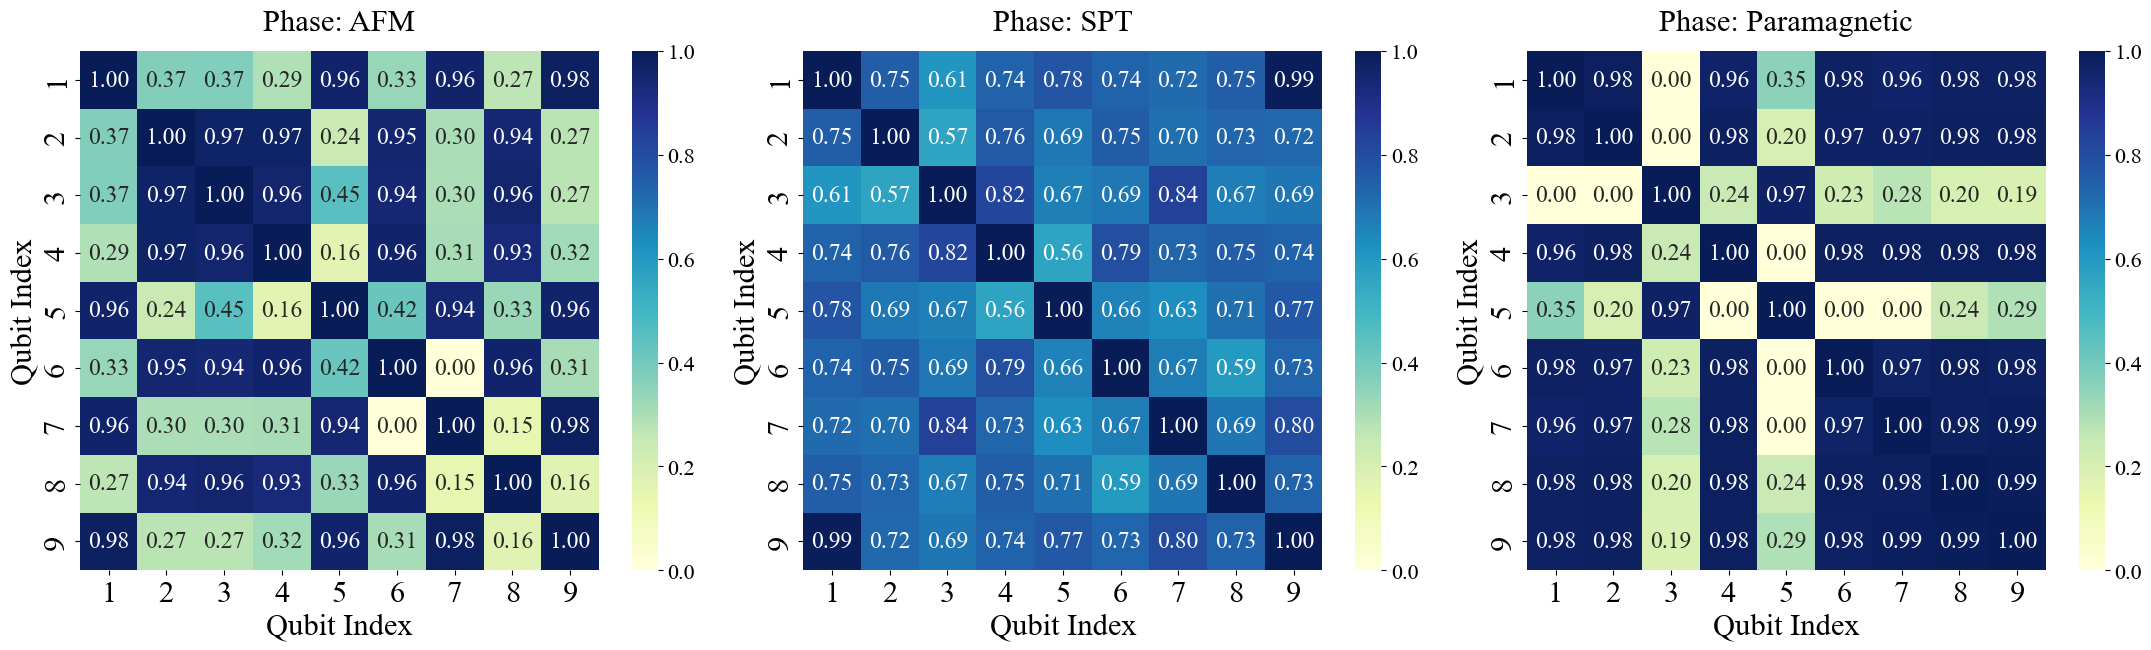

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
def visualize_matrices_with_values(model, inputs, outputs, phase_names=None):
    """
    可视化三个相的注意力矩阵。
    顺序已调整为: Antiferromagnetic (2), SPT (1), Paramagnetic (0)
    """
    if phase_names is None:
        phase_names = ["Antiferromagnetic", "SPT", "Paramagnetic"]
    
    # --- 修改点：调整字典顺序 ---
    # 按照 2 -> 1 -> 0 的顺序排列，确保绘图逻辑按此顺序执行
    label_map = {
        2: "AFM", 
        1: "SPT", 
        0: "Paramagnetic"
    }
    
    model.eval()
    selected_indices = []
    found_phases = []

    with torch.no_grad():
        # 字典是有序的，循环将按照 2, 1, 0 的顺序进行
        for label, name in label_map.items():
            label_indices = (outputs == label).nonzero(as_tuple=True)[0]
            
            if len(label_indices) > 0:
                random_local_idx = torch.randint(0, len(label_indices), (1,)).item()
                idx = label_indices[random_local_idx].item()
                
                selected_indices.append(idx)
                found_phases.append(name)

        if not selected_indices:
            print("错误：未在数据集中找到对应的相标签。")
            return

        # 绘图部分保持不变
        fig, axes = plt.subplots(1, len(selected_indices), figsize=(22, 6))
        plt.rcParams["font.family"] = "Times New Roman"
        
        if len(selected_indices) == 1:
            axes = [axes]

        for i, idx in enumerate(selected_indices):
            sample_input = inputs[idx].unsqueeze(0)
            _, matrix = model(sample_input)
            mat_np = matrix.squeeze().detach().cpu().numpy()
            
            num_qubits = mat_np.shape[0]
            tick_labels = [str(j + 1) for j in range(num_qubits)]
            
            hmap = sns.heatmap(mat_np, 
                               annot=True, 
                               fmt=".2f", 
                               cmap="YlGnBu", 
                               ax=axes[i], 
                               cbar=True, 
                               square=True,
                               vmin=0, vmax=1, 
                               annot_kws={"size": 17}, 
                               xticklabels=tick_labels, 
                               yticklabels=tick_labels) 
            
            axes[i].set_title(f"Phase: {found_phases[i]}", fontsize=22, pad=15)
            axes[i].set_xlabel("Qubit Index", fontsize=22)
            axes[i].set_ylabel("Qubit Index", fontsize=22)
            axes[i].tick_params(axis='both', labelsize=22)
            
            cbar = hmap.collections[0].colorbar
            if cbar:
                cbar.ax.tick_params(labelsize=16)
        
        plt.tight_layout()
        plt.show()
visualize_matrices_with_values(model, x_test, y_test)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_127200\2167309613.py:82: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax1.legend(lines, labs, loc='lower right', ncol=5)


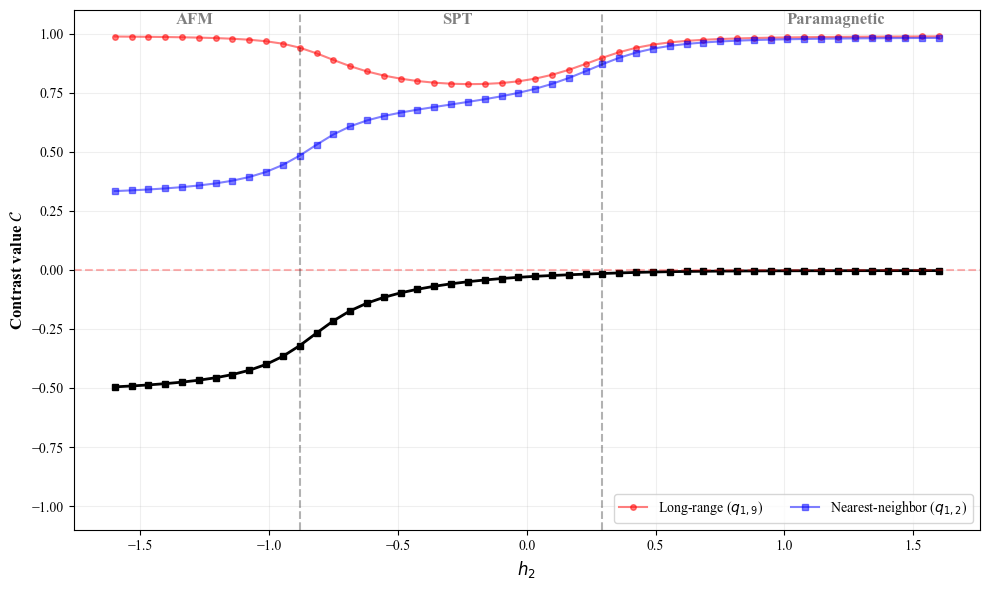

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_combined_evolution_consistent(model, x_test, y_test, target_h1=0.39):
    # --- 1. 参数与网格映射 ---
    h1s, h2s = 50, 50
    h1_grid = np.linspace(0, 1.2, h1s)
    h2_grid = np.linspace(-1.6, 1.6, h2s)
    
    h1_col_idx = np.abs(h1_grid - target_h1).argmin()
    actual_h1 = h1_grid[h1_col_idx]
    start_idx = h1_col_idx * h2s
    end_idx = start_idx + h2s
    
    q01_vals, q08_vals, contrast_vals, entropy_vals = [], [], [], []
    
    # --- 2. 提取数据 ---
    model.eval()
    with torch.no_grad():
        for i in range(start_idx, end_idx):
            _, matrix = model(x_test[i].unsqueeze(0))
            mat = matrix.squeeze().cpu().numpy()
            
            q01, q08 = mat[0, 1], mat[6, 8]
            q01_vals.append(q01)
            q08_vals.append(q08)
            
            # 对比度 C = (q01 - q08) / (q01 + q08 + 1e-9)
            contrast_vals.append((q01 - q08) / (q01 + q08 + 1e-9))
            
            # 注意力熵
            p = mat.flatten()
            p = p[p > 1e-10]
            entropy_vals.append(-np.sum(p * np.log(p)))

    # --- 3. 绘图 ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # A. 绘制左轴 (权重与对比度)
    # 这里的黑线格式完全参考你的第二个函数: 'k-s', markersize=4, linewidth=2
    line1 = ax1.plot(h2_grid, q08_vals, 'r-o', markersize=4, label='Long-range ($q_{1,9}$)', alpha=0.5)
    line2 = ax1.plot(h2_grid, q01_vals, 'b-s', markersize=4, label='Nearest-neighbor ($q_{1,2}$)', alpha=0.5)
    # line3 = ax1.plot(h2_grid, contrast_vals, 'k-s', markersize=4, linewidth=2, label=r'Contrast $\mathcal{C}$')
    line3 = ax1.plot(h2_grid, contrast_vals, 'k-s', markersize=4, linewidth=2)
    
    # 红色水平参考线 (参考你的第二个函数)
    ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
    
    ax1.set_xlabel('$h_2$', fontsize=12)
    # ax1.set_ylabel('Weight / Order Parameter $\mathcal{C}$', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Contrast value $\mathcal{C}$', fontsize=12, fontweight='bold')
    ax1.set_ylim(-1.1, 1.1)

    # B. 绘制右轴 (熵)
    # ax2 = ax1.twinx()
    # 参考你的第二个函数格式: 'g--', alpha=0.6
    # line4 = ax2.plot(h2_grid, entropy_vals, 'g--', alpha=0.6, label='Attention Entropy')
    # ax2.set_ylabel('Entropy $S_{att}$', color='g', fontsize=12)

    # --- 4. 标注相边界与标签 (参考你的第一个函数) ---
    labels = y_test[start_idx : end_idx].cpu().numpy()
    cps = np.where(labels[:-1] != labels[1:])[0]
    for cp in cps:
        ax1.axvline(h2_grid[cp], color='black', linestyle='--', alpha=0.3)

    # 标注相区文字 (参考你的第一个函数名称)
    y_pos = 1.04
    ax1.text(-1.29, y_pos, "AFM", fontsize=12, fontweight='bold', alpha=0.5, ha='center')
    ax1.text(-0.27, y_pos, "SPT", fontsize=12, fontweight='bold', alpha=0.5, ha='center')
    ax1.text(1.2, y_pos, "Paramagnetic", fontsize=12, fontweight='bold', alpha=0.5, ha='center')

    # --- 5. 整合与显示 ---
    # 使用 r"..." 原始字符串避免 LaTeX 渲染问题
    # plt.title(r"Combined Evolution of Attention Metrics (Fixed $h_1 \approx " + f"{actual_h1:.2f}" + r"$)", fontsize=14)
    
    ax1.grid(True, alpha=0.2)
    
    # 合并图例
    lines =  line1+line2+line3 # +line4
    labs = [l.get_label() for l in lines]
    ax1.legend(lines, labs, loc='lower right', ncol=5)

    plt.tight_layout()
    plt.show()
    return contrast_vals

# 调用
contrast_values=plot_combined_evolution_consistent(model, x_test, y_test, target_h1=0.39)

In [17]:
# contrast_values = np.array(contrast_values)
# np.save("contrast_values9.npy", contrast_values)  # 保存为 .npy

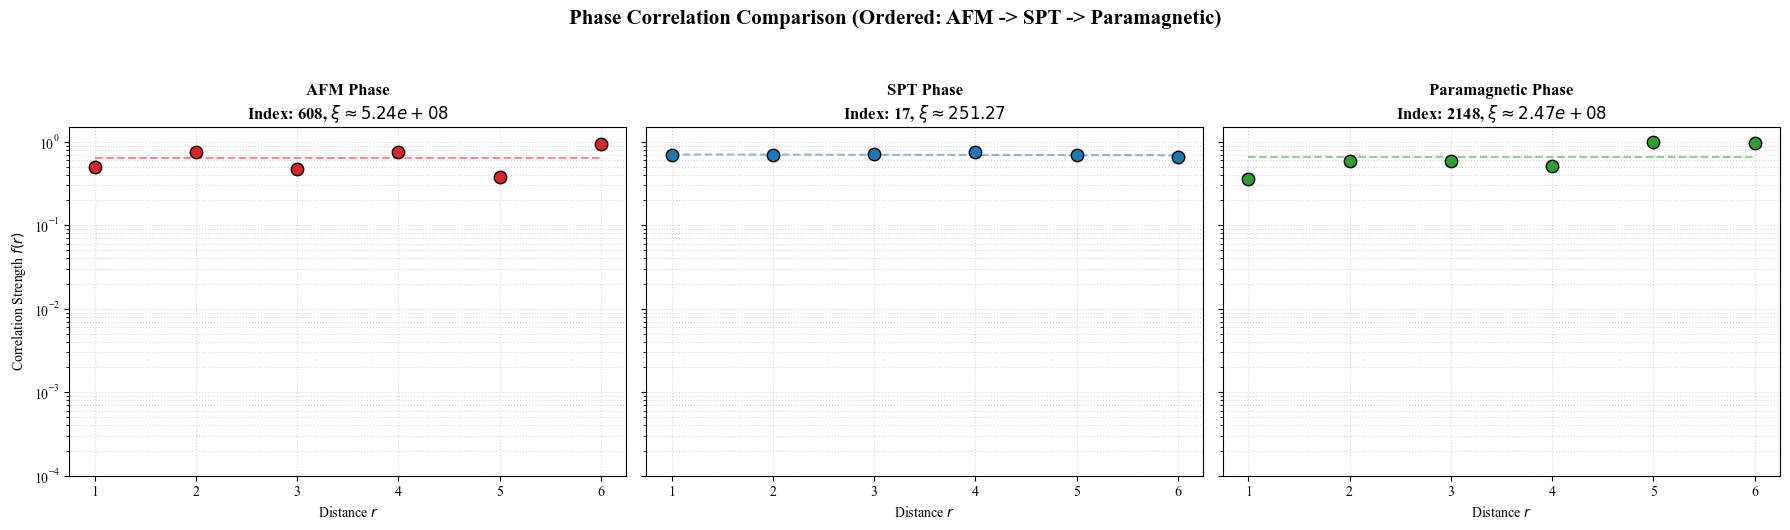

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.optimize import curve_fit
import random

def plot_phases_ordered_afm_first(model, x_test, y_test):
    # 1. 修正后的映射（根据你的指正）
    # 标签 2: AFM (反铁磁), 1: SPT (拓扑), 0: Paramagnetic (顺磁)
    phase_order = [2, 1, 0] 
    phase_names = {2: "AFM Phase", 1: "SPT Phase", 0: "Paramagnetic Phase"}
    colors = {2: 'tab:red', 1: 'tab:blue', 0: 'tab:green'}
    
    # 2. 随机选取每个相的一个样本索引
    selected_indices = {}
    for label in phase_order:
        label_indices = (y_test == label).nonzero(as_tuple=True)[0].cpu().numpy()
        if len(label_indices) > 0:
            selected_indices[label] = random.choice(label_indices)

    # 3. 绘图：1行3列，顺序为 AFM -> SPT -> Paramagnetic
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    model.eval()
    
    def exp_func(r, a, xi): return a * np.exp(-r / xi)

    with torch.no_grad():
        for i, label in enumerate(phase_order):
            if label not in selected_indices: continue
            
            idx = selected_indices[label]
            ax = axes[i]
            
            # 获取注意力矩阵并计算 f(r)
            _, matrix = model(x_test[idx].unsqueeze(0))
            mat = matrix.squeeze().cpu().numpy()
            mat = mat[0 : 7 , 0 : 7]
            num_qubits = mat.shape[0]
            r_range = np.arange(1, num_qubits)
            f_r = [np.mean(np.abs(np.diag(mat, k=r))) for r in r_range]
            
            # 拟合关联长度 xi
            xi_str = "N/A"
            try:
                # 给定初值进行拟合
                popt, _ = curve_fit(exp_func, r_range, f_r, p0=[0.5, 1.0], maxfev=2000)
                xi_val = popt[1]
                # 针对极大值使用科学计数法
                xi_str = f"{xi_val:.2f}" if xi_val < 1000 else f"{xi_val:.2e}"
                
                r_fit = np.linspace(1, num_qubits-1, 100)
                ax.plot(r_fit, exp_func(r_fit, *popt), '--', color=colors[label], alpha=0.5)
            except: pass
            
            # 绘制散点
            ax.scatter(r_range, f_r, color=colors[label], s=80, edgecolors='k', zorder=3)
            
            # 标题信息
            ax.set_title(f"{phase_names[label]}\nIndex: {idx}, $\\xi \\approx {xi_str}$", 
                         fontsize=12, fontweight='bold')
            ax.set_xlabel("Distance $r$")
            ax.set_yscale('log')
            ax.set_ylim(1e-4, 1.5)
            ax.grid(True, which='both', linestyle=':', alpha=0.5)
            
    axes[0].set_ylabel("Correlation Strength $f(r)$")
    plt.suptitle("Phase Correlation Comparison (Ordered: AFM -> SPT -> Paramagnetic)", 
                 fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# 运行代码
plot_phases_ordered_afm_first(model, x_test, y_test)

开始计算关联长度 (xi)，固定 h1 ≈ 0.20


C:\Users\Administrator\AppData\Local\Temp\ipykernel_127200\2579895394.py:51: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(exponential_decay, r_range, f_r, p0=[0, 1.0], maxfev=2000)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_127200\2579895394.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


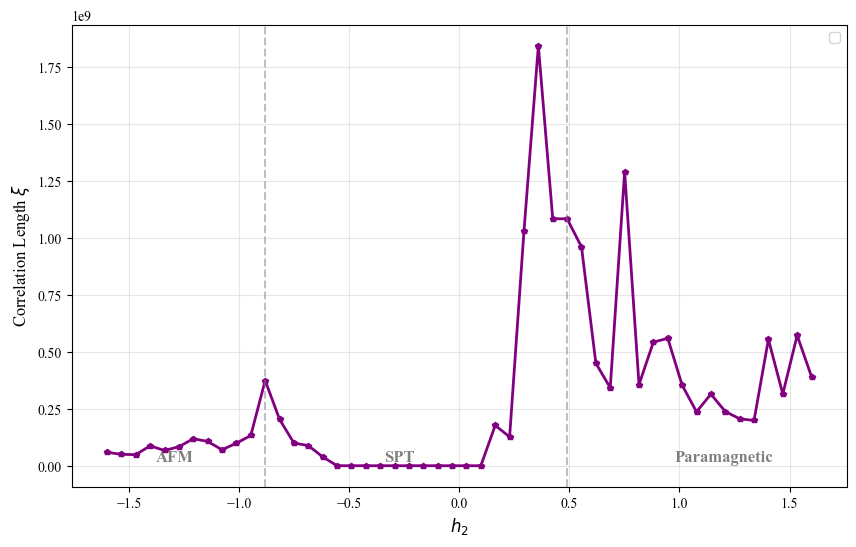

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.optimize import curve_fit

def exponential_decay(r, a, xi):
    """
    定义关联函数衰减公式: f(r) = a * exp(-r / xi)
    xi 即为我们需要提取的关联长度
    """
    return a * np.exp(-r / xi)

def calculate_and_plot_xi(model, x_test, y_test, target_h1=0.39):
    # --- 1. 参数定位 ---
    h1s, h2s = 50, 50
    h1_grid = np.linspace(0, 1.2, h1s)
    h2_grid = np.linspace(-1.6, 1.6, h2s)
    
    # 找到最接近 target_h1 的列索引
    h1_col_idx = np.abs(h1_grid - target_h1).argmin()
    actual_h1 = h1_grid[h1_col_idx]
    start_idx = h1_col_idx * h2s
    end_idx = start_idx + h2s
    
    xi_values = []
    h2_axis = h2_grid
    
    print(f"开始计算关联长度 (xi)，固定 h1 ≈ {actual_h1:.2f}")
    model.eval()
    
    # --- 2. 遍历扫描线计算每个点的 xi ---
    with torch.no_grad():
        for i in range(start_idx, end_idx):
            # 获取注意力矩阵 [9, 9]
            _, matrix = model(x_test[i].unsqueeze(0))
            mat = matrix.squeeze().cpu().numpy()
            sub_mat = mat[0 : 7 , 0 : 7]
            # 计算不同距离 r 的平均关联强度 f(r)
            num_qubits = sub_mat.shape[0]
            r_range = np.arange(1, num_qubits) # r = 1, 2, ..., 8
            f_r = []
            
            for r in r_range:
                # 提取距离为 r 的对角线元素并求平均
                diags = np.diag(sub_mat, k=r)
                f_r.append(np.mean(np.abs(diags)))
            
            # 3. 拟合计算 xi
            try:
                # p0=[初始振幅, 初始xi猜测值]
                popt, _ = curve_fit(exponential_decay, r_range, f_r, p0=[0, 1.0], maxfev=2000)
                xi_values.append(popt[1]) 
            except Exception:
                # 如果拟合失败（如关联极弱），设为0
                xi_values.append(0)
    
    # --- 4. 可视化 ---
    # plt.figure(figsize=(8, 6))
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # 绘制 xi 曲线
    plt.plot(h2_axis, xi_values, color='purple', marker='p', markersize=4, 
             linewidth=2)
    
    # 标注相边界（根据 y_test 标签跳变）
    y_pos = 2e7
    ax1.text(-1.29, y_pos, "AFM", fontsize=12, fontweight='bold', alpha=0.5, ha='center')
    ax1.text(-0.27, y_pos, "SPT", fontsize=12, fontweight='bold', alpha=0.5, ha='center')
    ax1.text(1.2, y_pos, "Paramagnetic", fontsize=12, fontweight='bold', alpha=0.5, ha='center')

    labels = y_test[start_idx : end_idx].cpu().numpy()
    change_points = np.where(labels[:-1] != labels[1:])[0]
    for cp in change_points:
        plt.axvline(h2_axis[cp], color='gray', linestyle='--', alpha=0.5)
        # plt.text(h2_axis[cp], max(xi_values)*0.9, ' Phase Boundary', color='gray')

    # plt.title(r"Evolution of Effective Correlation Length $\xi$ along $h_2$", fontsize=14)
    plt.xlabel(r"$h_2$", fontsize=12)
    plt.ylabel(r"Correlation Length $\xi$", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    return xi_values

# --- 调用执行 ---
xi_values =calculate_and_plot_xi(model, x_test, y_test, target_h1=0.2)

In [20]:
# xi_values = np.array(xi_values)
# np.save("xi_values9.npy", xi_values)  # 保存为 .npy